<a href="https://colab.research.google.com/github/Ronaa-MX/simulacion-esfm/blob/simulacion-I/Ejemplo3_14_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Prónostico de inventario de producto

Tendremos que se vende un producto famoso, los productores del mismo desean saber cuantos pedir en base a la distribución de sus ventas en 3 años por cada mes.

In [13]:
# Librerías a usar
import random as rd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plot
from multiprocessing import Pool, cpu_count
import time

In [2]:
# ------------------------------------------------------------
# 1-3. Variables, probabilidades y CDF
# ------------------------------------------------------------
demandas = np.array([100, 200, 300, 400, 500, 600])
probs = np.array([0.22, 0.25, 0.11, 0.25, 0.11, 0.06])
cdf = np.cumsum(probs)   # [0.22, 0.47, 0.58, 0.83, 0.94, 1.00]


In [3]:

# ------------------------------------------------------------
# 4. Generación vectorizada de demanda
# ------------------------------------------------------------
def generar_demanda(n):
    u = np.random.uniform(0, 1, n)
    idx = np.searchsorted(cdf, u)
    return demandas[idx]

In [4]:
# ------------------------------------------------------------
# 5. Función de beneficio diario (vectorizada)
# ------------------------------------------------------------
def beneficio_diario(demanda, compras=400):
    precio_venta = 1000
    costo = 750
    precio_dev = 250
    ventas_reales = np.minimum(demanda, compras)
    devoluciones = compras - ventas_reales
    ingresos_ventas = ventas_reales * precio_venta
    ingresos_dev = devoluciones * precio_dev
    costo_total = compras * costo
    return ingresos_ventas + ingresos_dev - costo_total

In [20]:
# ------------------------------------------------------------
# Experimento: simular N días y devolver beneficio medio diario
# ------------------------------------------------------------
def experimento(N_dias, compras=400):
    demandas_dia = generar_demanda(N_dias)
    beneficios = beneficio_diario(demandas_dia, compras)
    return np.mean(beneficios)

In [19]:
# ------------------------------------------------------------
# 7. Paralelización de M experimentos
# ------------------------------------------------------------
def simulacion_paralela(M, N_dias, compras=400):
    with Pool(processes=cpu_count()) as pool:
        args = [(N_dias, compras)] * M
        resultados = pool.starmap(experimento, args)
    return np.array(resultados)

In [21]:
# ------------------------------------------------------------
# 6. Gráfico de convergencia (promedio acumulado en una ejecución larga)
# ------------------------------------------------------------
def graficar_convergencia(N_dias_largos=20000, compras=400):
    demandas = generar_demanda(N_dias_largos)
    beneficios = beneficio_diario(demandas, compras)
    promedios_acum = np.cumsum(beneficios) / np.arange(1, N_dias_largos+1)
    
    plot.figure(figsize=(10, 5))
    plot.plot(range(1, N_dias_largos+1), promedios_acum, linewidth=0.8, color='blue')
    plot.axhline(y=np.mean(beneficios), color='red', linestyle='--', 
                label=f'Media final = {np.mean(beneficios):.2f}')
    plot.xlabel('Días')
    plot.ylabel('Beneficio medio acumulado (€/día)')
    plot.title('Convergencia del beneficio medio diario')
    plot.legend()
    plot.grid(alpha=0.3)
    plot.show()

Generando gráfico de convergencia...


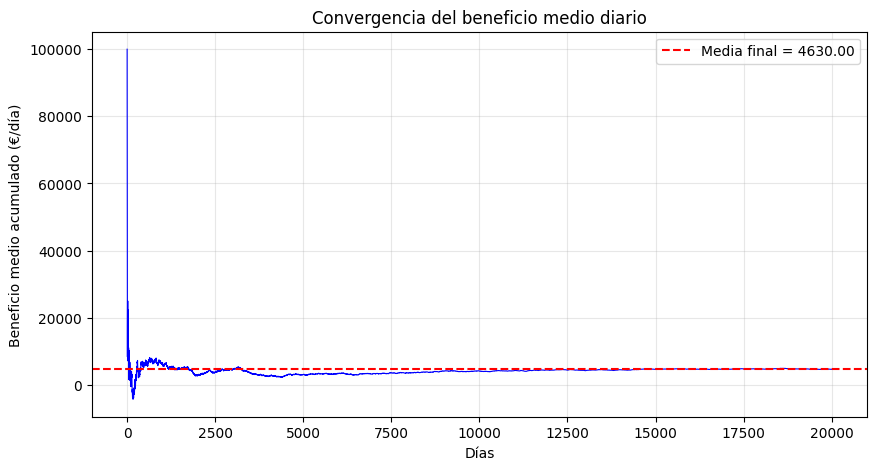

Ejecutando 10000 experimentos con 1000 días cada uno...
Tiempo total: 0.65 segundos

===== RESULTADOS =====
Beneficio medio diario esperado (simulado): 4793.01 €
Desviación estándar de las medias: 2866.23 €
Varianza: 8215282.19
Intervalo de confianza del 95%: ([-824.71,10410.72) €


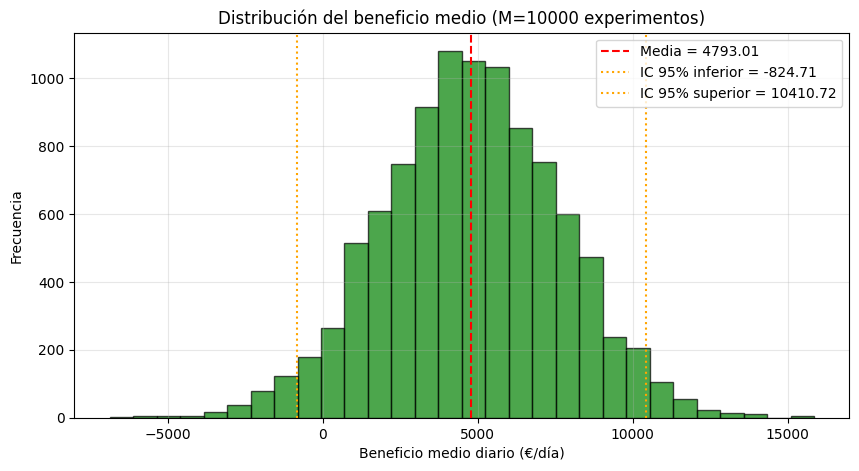

In [25]:
# ------------------------------------------------------------
# Parámetros de simulación
# ------------------------------------------------------------
N_DIAS_POR_EXPERIMENTO = 1000   # días por cada experimento
M_EXPERIMENTOS = 10000           # número de experimentos (corridas)
COMPRAS = 400

# ------------------------------------------------------------
# Ejecución
# ------------------------------------------------------------
if __name__ == "__main__":
    # Mostrar gráfico de convergencia con una simulación larga
    print("Generando gráfico de convergencia...")
    graficar_convergencia(N_dias_largos=20000, compras=COMPRAS)
    
    # Simulación paralela
    print(f"Ejecutando {M_EXPERIMENTOS} experimentos con {N_DIAS_POR_EXPERIMENTO} días cada uno...")
    inicio = time.time()
    resultados = simulacion_paralela(M_EXPERIMENTOS, N_DIAS_POR_EXPERIMENTO, COMPRAS)
    fin = time.time()
    print(f"Tiempo total: {fin - inicio:.2f} segundos")
    
    # 9. Estadísticos
    mean = np.mean(resultados)
    std = np.std(resultados)  
    varianza = np.var(resultados)
    
    # 10. Intervalo de confianza del 95%
    alpha = 0.95
    confidence_mean = st.norm.interval(alpha,loc=mean,scale=std)
    
    print("\n===== RESULTADOS =====")
    print(f"Beneficio medio diario esperado (simulado): {mean:.2f} €")
    print(f"Desviación estándar de las medias: {std:.2f} €")
    print(f"Varianza: {varianza:.2f}")
    print("Intervalo de confianza del 95%: ([{:.2f},{:.2f}) €".format(*confidence_mean))
    
    # 8. Histograma de los resultados
    plot.figure(figsize=(10, 5))
    plot.hist(resultados, bins=30, alpha=0.7, color='green', edgecolor='black')
    plot.axvline(mean, color='red', linestyle='--', label=f'Media = {mean:.2f}')
    plot.axvline(confidence_mean[0], color='orange', linestyle=':', label=f'IC 95% inferior = {confidence_mean[0]:.2f}')
    plot.axvline(confidence_mean[1], color='orange', linestyle=':', label=f'IC 95% superior = {confidence_mean[1]:.2f}')
    plot.xlabel('Beneficio medio diario (€/día)')
    plot.ylabel('Frecuencia')
    plot.title(f'Distribución del beneficio medio (M={M_EXPERIMENTOS} experimentos)')
    plot.legend()
    plot.grid(alpha=0.3)
    plot.show()